# Fixture-Proof Players — Playground #5

Is a player a **flat-track bully** or the **real deal**? We split every player's 2024/25 returns by the *context* of each match and ask who keeps delivering regardless.

Two axes of the same question (spec: [brainstorming/12](../../brainstorming/12-fixture-proof-players.md)):
- **Opponent tier** — top-6 / middle-8 / bottom-6 by the **final league table**.
- **Venue** — home vs away.

**CS problem:** *stratified aggregation + a group-difference test*. Build a `player × bucket` **points-per-90** matrix, then compare buckets. Ranking by season mean is the naive sort; ranking by the **gradient** (bottom-tier PP90 − top-tier PP90, or home − away) is the honest one — it separates fixture-dependent hauls from fixture-proof output.

**Method**
1. Derive the final table from match results → map each opponent to a tier.
2. PP90 per (player, bucket); minutes guard per bucket so small samples don't lie.
3. Gradient + mean PP90 → verdict; same machinery for both axes.
4. Heatmap + the mean-vs-gradient scatter (the money shot).


## Config — edit me

In [1]:
SEASON = "2024-25"
BASE = f"https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{SEASON}"
MERGED_URL   = f"{BASE}/gws/merged_gw.csv"
FIXTURES_URL = f"{BASE}/fixtures.csv"
TEAMS_URL    = f"{BASE}/teams.csv"

# Tier sizes over the final table (must sum to 20).
TOP_N, MID_N, BOT_N = 6, 8, 6

# Minutes a player must log *within a bucket* before that bucket's PP90 counts.
# 270 = roughly three full matches. Thin buckets are flagged, not silently dropped.
MIN_MINUTES_PER_BUCKET = 270

# Season-total minutes floor to even appear (drops fringe/cameo players).
MIN_TOTAL_MINUTES = 1500

# The analysis universe: top N scorers per position (by TOTAL points), set per position.
# Everything downstream — splits, heatmaps, scatter, combined — runs on this set.
TOP_PER_POS = {"GK": 4, "DEF": 10, "MID": 10, "FWD": 6}

# How many players to show in the heatmaps / leaderboards.
TOP_K = 20


## Fetch

In [2]:
import io, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_csv(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    return pd.read_csv(io.BytesIO(urllib.request.urlopen(req, timeout=60).read()))

gw       = read_csv(MERGED_URL)
fixtures = read_csv(FIXTURES_URL)
teams    = read_csv(TEAMS_URL)

team_name = dict(zip(teams["id"], teams["short_name"]))
print(f"{len(gw):,} player-GW rows | {gw['name'].nunique()} players | GWs {gw['round'].min()}–{gw['round'].max()}")


27,605 player-GW rows | 805 players | GWs 1–38


## Final table → opponent tiers

`teams.csv` positions are a pre-season snapshot (all zeros), so we compute the real standings from finished match results, then slice top-6 / middle-8 / bottom-6.

In [3]:
fin = fixtures[(fixtures["finished"] == True) & fixtures["team_h_score"].notna()].copy()

rows = []
for _, f in fin.iterrows():
    hs, as_ = int(f["team_h_score"]), int(f["team_a_score"])
    hp, ap = (3, 0) if hs > as_ else (0, 3) if hs < as_ else (1, 1)
    rows.append((f["team_h"], hp, hs - as_))
    rows.append((f["team_a"], ap, as_ - hs))

standings = (pd.DataFrame(rows, columns=["team", "pts", "gd"])
             .groupby("team").agg(pts=("pts", "sum"), gd=("gd", "sum"))
             .sort_values(["pts", "gd"], ascending=False).reset_index())
standings["position"] = np.arange(1, len(standings) + 1)
standings["short"] = standings["team"].map(team_name)

def tier_of(pos):
    if pos <= TOP_N: return "top"
    if pos <= TOP_N + MID_N: return "mid"
    return "bot"
standings["tier"] = standings["position"].map(tier_of)
opp_tier = dict(zip(standings["team"], standings["tier"]))

print(standings[["position", "short", "pts", "gd", "tier"]].to_string(index=False))


 position short  pts  gd tier
        1   LIV   84  45  top
        2   ARS   74  35  top
        3   MCI   71  28  top
        4   CHE   69  21  top
        5   NEW   66  21  top
        6   AVL   66   7  top
        7   NFO   65  12  mid
        8   BHA   61   7  mid
        9   BOU   56  12  mid
       10   BRE   56   9  mid
       11   FUL   54   0  mid
       12   CRY   53   0  mid
       13   EVE   48  -2  mid
       14   WHU   43 -16  mid
       15   MUN   42 -10  bot
       16   WOL   42 -15  bot
       17   TOT   38  -1  bot
       18   LEI   25 -47  bot
       19   IPS   22 -46  bot
       20   SOU   12 -60  bot


## The PP90-by-bucket engine

One helper does both axes: group by `(name, bucket)`, sum points and minutes, divide to points-per-90. A bucket with fewer than `MIN_MINUTES_PER_BUCKET` is set to `NaN` (flagged, not counted).

In [4]:
df = gw.copy()
df["opp_tier"] = df["opponent_team"].map(opp_tier)
df["venue"] = np.where(df["was_home"], "home", "away")

# meta per player (position/team/season minutes) for filtering + labels
meta = (df.groupby("name")
          .agg(position=("position", "first"), team=("team", "first"),
               tot_min=("minutes", "sum"), tot_pts=("total_points", "sum"))
          .reset_index())
meta["pp90"] = meta["tot_pts"] / meta["tot_min"] * 90

# Universe = the top-N scorers per position by TOTAL points, where N varies by position
# (see TOP_PER_POS). A minutes floor first stops a high-per-90 cameo sneaking in.
ranked = meta[meta["tot_min"] >= MIN_TOTAL_MINUTES].sort_values("tot_pts", ascending=False)
within_cap = ranked.groupby("position").cumcount() < ranked["position"].map(TOP_PER_POS).fillna(0)
top_by_pos = ranked[within_cap]
eligible = set(top_by_pos["name"])
print(f"universe: {len(eligible)} players — top-per-position {TOP_PER_POS}")
print(top_by_pos["position"].value_counts().to_dict())

def pp90_matrix(bucket_col, order):
    """Return a player × bucket PP90 frame + parallel minutes frame (for flags)."""
    g = (df[df["name"].isin(eligible)]
         .groupby(["name", bucket_col])
         .agg(pts=("total_points", "sum"), mins=("minutes", "sum")).reset_index())
    pts = g.pivot(index="name", columns=bucket_col, values="pts").reindex(columns=order)
    mins = g.pivot(index="name", columns=bucket_col, values="mins").reindex(columns=order)
    pp90 = (pts / mins * 90).where(mins >= MIN_MINUTES_PER_BUCKET)
    return pp90, mins


universe: 30 players — top-per-position {'GK': 4, 'DEF': 10, 'MID': 10, 'FWD': 6}
{'MID': 10, 'DEF': 10, 'FWD': 6, 'GK': 4}


## Axis A — opponent tier

**Gradient = PP90(bottom-6) − PP90(top-6).** High mean + flat gradient = *fixture-proof*. High mean + steep positive gradient = flat-track bully (only turns up against weak teams).

In [5]:
tier_order = ["top", "mid", "bot"]
pp90_tier, mins_tier = pp90_matrix("opp_tier", tier_order)

tierA = pp90_tier.join(meta.set_index("name")[["position", "team", "pp90"]])
tierA = tierA.rename(columns={"top": "vs_top", "mid": "vs_mid", "bot": "vs_bot", "pp90": "mean_pp90"})
tierA["gradient"] = tierA["vs_bot"] - tierA["vs_top"]

def verdict(row, g_col="gradient", flat=1.0):
    if pd.isna(row[g_col]): return "thin sample"
    if abs(row[g_col]) <= flat: return "fixture-proof"
    return "flat-track bully" if row[g_col] > 0 else "steps up"
tierA["verdict"] = tierA.apply(verdict, axis=1)

show = (tierA.sort_values("mean_pp90", ascending=False).head(TOP_K)
        [["position", "vs_top", "vs_mid", "vs_bot", "gradient", "mean_pp90", "verdict"]]
        .round(2))
show


,position,vs_top,vs_mid,vs_bot,gradient,mean_pp90,verdict
name,,,,,,,
Mohamed Salah,MID,10.38,6.92,11.12,0.74,9.18,fixture-proof
Alexander Isak,FWD,5.86,5.31,9.65,3.79,6.89,flat-track bully
Luis Díaz,MID,6.00,6.99,7.33,1.33,6.88,flat-track bully
Ollie Watkins,FWD,5.49,7.82,5.39,-0.10,6.46,fixture-proof
Bryan Mbeumo,MID,4.42,5.74,8.58,4.17,6.22,flat-track bully
Matheus Santos Carneiro Da Cunha,FWD,4.28,5.14,10.91,6.63,6.17,flat-track bully
Chris Wood,FWD,3.84,6.34,7.90,4.07,6.09,flat-track bully
Justin Kluivert,MID,6.76,5.32,6.23,-0.53,6.08,fixture-proof
Jacob Murphy,MID,3.15,6.18,8.30,5.16,6.07,flat-track bully


### Heatmap — PP90 by opponent tier (top players by mean)

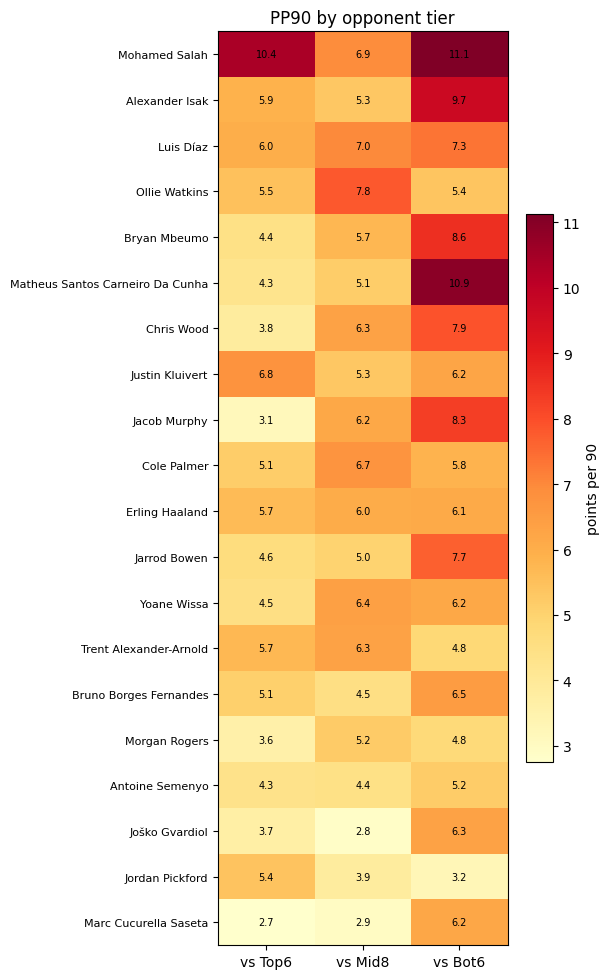

In [6]:
def heatmap(mat, cols, collabels, title):
    top = mat.sort_values("mean_pp90", ascending=False).head(TOP_K)
    M = top[cols].values.astype(float)
    fig, ax = plt.subplots(figsize=(6, 0.42 * len(top) + 1.5))
    im = ax.imshow(M, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(collabels)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            ax.text(j, i, "–" if np.isnan(v) else f"{v:.1f}", ha="center", va="center", fontsize=7)
    ax.set_title(title); fig.colorbar(im, ax=ax, label="points per 90", shrink=0.6)
    plt.tight_layout(); plt.show()

heatmap(tierA, ["vs_top", "vs_mid", "vs_bot"], ["vs Top6", "vs Mid8", "vs Bot6"],
        "PP90 by opponent tier")


### Money shot — mean PP90 vs tier gradient

**Top-left** (high mean, gradient ≈ 0) is the fixture-proof elite. **Top-right** is high output that leans on easy fixtures.

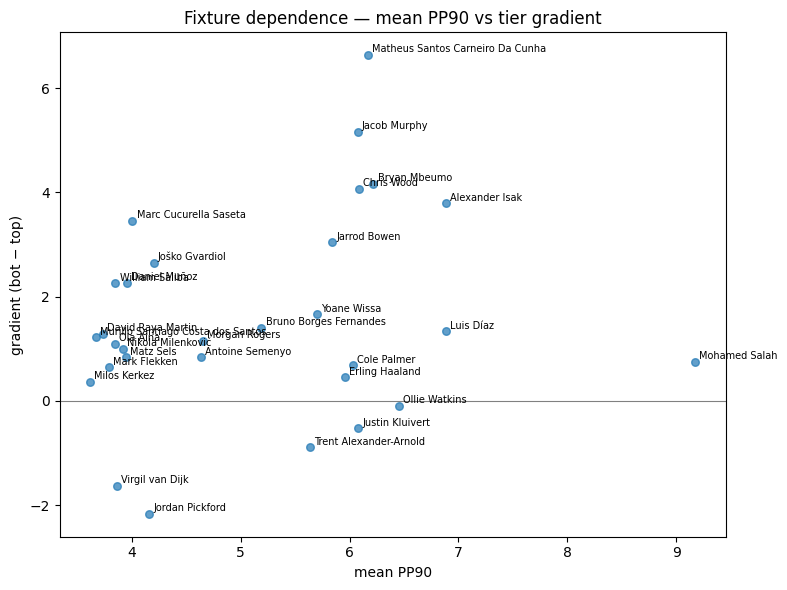

In [7]:
def scatter(mat, title, xlab="mean PP90", ylab="gradient (bot − top)"):
    d = mat.dropna(subset=["gradient", "mean_pp90"])
    d = d.sort_values("mean_pp90", ascending=False).head(40)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(d["mean_pp90"], d["gradient"], s=30, alpha=0.7)
    ax.axhline(0, color="grey", lw=0.8)
    for name, r in d.iterrows():
        ax.annotate(name, (r["mean_pp90"], r["gradient"]), fontsize=7,
                    xytext=(3, 2), textcoords="offset points")
    ax.set_xlabel(xlab); ax.set_ylabel(ylab); ax.set_title(title)
    plt.tight_layout(); plt.show()

scatter(tierA, "Fixture dependence — mean PP90 vs tier gradient")


## Axis B — venue (home / away)

Same engine, bucket = venue. **Gradient = PP90(home) − PP90(away).** Flat ≈ venue-proof; large positive = away-day no-show.

In [8]:
venue_order = ["home", "away"]
pp90_venue, mins_venue = pp90_matrix("venue", venue_order)

venueB = pp90_venue.join(meta.set_index("name")[["position", "team", "pp90"]])
venueB = venueB.rename(columns={"pp90": "mean_pp90"})
venueB["gradient"] = venueB["home"] - venueB["away"]
venueB["verdict"] = venueB.apply(lambda r: verdict(r, flat=1.0), axis=1)

venueB.sort_values("mean_pp90", ascending=False).head(TOP_K)[
    ["position", "home", "away", "gradient", "mean_pp90", "verdict"]].round(2)


,position,home,away,gradient,mean_pp90,verdict
name,,,,,,
Mohamed Salah,MID,8.15,10.20,-2.05,9.18,steps up
Alexander Isak,FWD,7.07,6.66,0.42,6.89,fixture-proof
Luis Díaz,MID,7.58,6.04,1.54,6.88,flat-track bully
Ollie Watkins,FWD,6.61,6.28,0.33,6.46,fixture-proof
Bryan Mbeumo,MID,6.74,5.70,1.04,6.22,flat-track bully
Matheus Santos Carneiro Da Cunha,FWD,6.15,6.19,-0.04,6.17,fixture-proof
Chris Wood,FWD,6.10,6.07,0.02,6.09,fixture-proof
Justin Kluivert,MID,4.47,7.68,-3.21,6.08,steps up
Jacob Murphy,MID,6.76,5.39,1.37,6.07,flat-track bully


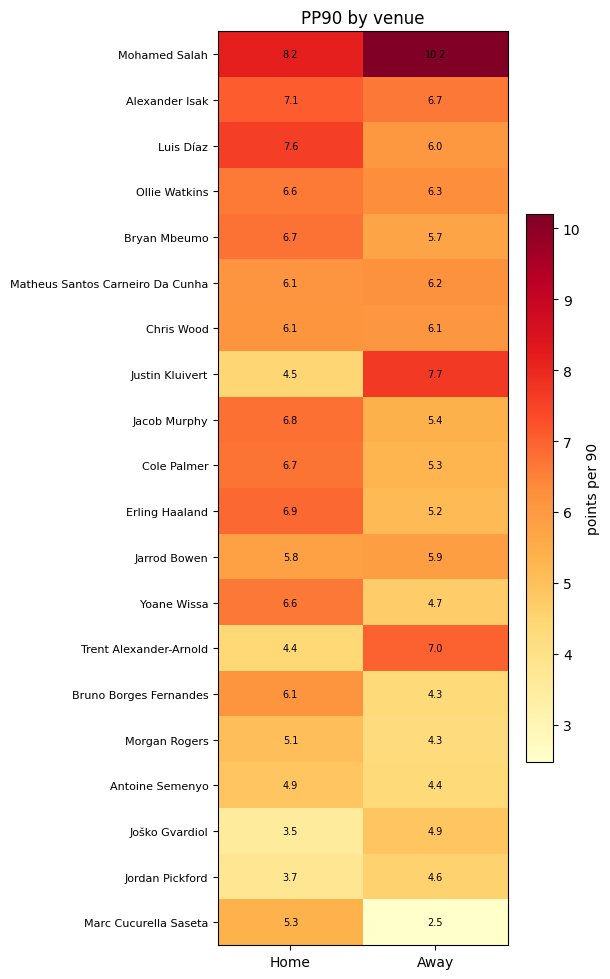

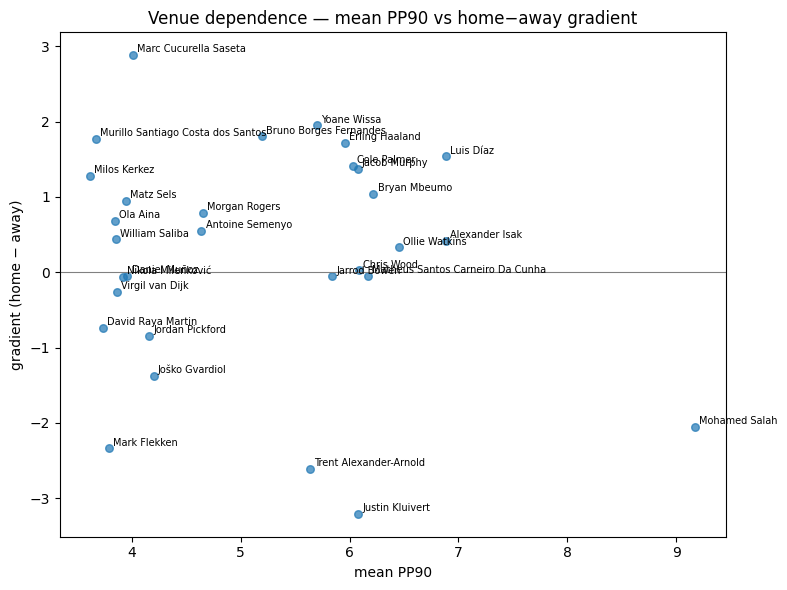

In [9]:
heatmap(venueB, ["home", "away"], ["Home", "Away"], "PP90 by venue")
scatter(venueB, "Venue dependence — mean PP90 vs home−away gradient",
        ylab="gradient (home − away)")


## Combined verdict — the master table

The whole universe in one place: **total points** (output) alongside **mean PP90** (rate) and both gradients (how those points were earned). Flat on **both** axes = the true set-and-forget asset; steep on both = the classic home-vs-weak flat-track bully. Ranked by mean PP90.

In [11]:
combined = (top_by_pos.set_index("name")[["position", "team", "tot_pts", "tot_min", "pp90"]]
            .rename(columns={"pp90": "mean_pp90"})
            .join(tierA["gradient"].rename("tier_grad"))
            .join(venueB["gradient"].rename("venue_grad")))
combined = combined.dropna(subset=["tier_grad", "venue_grad"])

def combined_label(r, flat=1.0):
    ft = abs(r["tier_grad"]) <= flat
    fv = abs(r["venue_grad"]) <= flat
    if ft and fv: return "set-and-forget (proof on both)"
    if not ft and r["tier_grad"] > 0 and r["venue_grad"] > 0: return "flat-track bully"
    if ft: return "fixture-proof only"
    if fv: return "venue-proof only"
    return "context-dependent"
combined["label"] = combined.apply(combined_label, axis=1)

# Master table for the whole piece: total output (tot_pts) + rate (mean_pp90) +
# how those points were earned (both gradients) + the verdict, ranked by rate.
combined.sort_values(["team", "mean_pp90"], ascending=[True, False])[
    ["position", "team", "tot_pts", "tot_min", "mean_pp90", "tier_grad", "venue_grad", "label"]].round(2)


,position,team,tot_pts,tot_min,mean_pp90,tier_grad,venue_grad,label
name,,,,,,,,
William Saliba,DEF,Arsenal,130,3039,3.85,2.25,0.44,flat-track bully
David Raya Martin,GK,Arsenal,142,3420,3.74,1.28,-0.74,venue-proof only
Ollie Watkins,FWD,Aston Villa,186,2593,6.46,-0.10,0.33,set-and-forget (proof on both)
Morgan Rogers,MID,Aston Villa,161,3115,4.65,1.16,0.79,flat-track bully
Justin Kluivert,MID,Bournemouth,158,2339,6.08,-0.53,-3.21,fixture-proof only
Antoine Semenyo,MID,Bournemouth,165,3202,4.64,0.83,0.55,set-and-forget (proof on both)
Milos Kerkez,DEF,Bournemouth,134,3336,3.62,0.36,1.28,fixture-proof only
Bryan Mbeumo,MID,Brentford,236,3415,6.22,4.17,1.04,flat-track bully
Yoane Wissa,FWD,Brentford,185,2921,5.70,1.66,1.95,flat-track bully
